# **Linear Regression SAT Scores vs GPA**

# **Dataset 1: SAT Score and High School GPA v/s College First Year GPA**

SAT and GPA data for 1000 students at an unnamed college.

1. sex - Gender of the student.

2. sat_v - Verbal SAT percentile.

3. sat_m - Math SAT percentile.

4. sat_sum - Total of verbal and math SAT percentiles.

5. hs_gpa - High school grade point average.

6. fy_gpa - First year (college) grade point average.

In [95]:
# Import all the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.graph_objects as go
warnings.filterwarnings('ignore')

In [96]:
# Read the dataset and create a dataframe for analysis. Print the first 5 rows
df = pd.read_csv("/content/drive/MyDrive/Datasets/satgpa.csv")
df.head()

,sex,sat_v,sat_m,sat_sum,hs_gpa,fy_gpa
0,1,65,62,127,3.40,3.18
1,2,58,64,122,4.00,3.33
2,2,56,60,116,3.75,3.25
3,1,42,53,95,3.75,2.42
4,1,55,52,107,4.00,2.63


In [97]:
# Print the last 5 rows
df.tail()

,sex,sat_v,sat_m,sat_sum,hs_gpa,fy_gpa
995,2,50,50,100,3.7,2.19
996,1,54,54,108,3.3,1.50
997,1,56,58,114,3.5,3.17
998,1,55,65,120,2.3,1.94
999,1,49,44,93,2.7,2.38


In [98]:
# Print the shape of the dataframe
df.shape

(1000, 6)

In [99]:
# Statistical summary of the numerical columns of the dataframe
df.describe()

,sex,sat_v,sat_m,sat_sum,hs_gpa,fy_gpa
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1.484000,48.93400,54.395000,103.329000,3.198100,2.467950
std,0.499994,8.23392,8.450111,14.287368,0.541647,0.740805
min,1.000000,24.00000,29.000000,53.000000,1.800000,0.000000
25%,1.000000,43.00000,49.000000,93.000000,2.800000,1.980000
50%,1.000000,49.00000,55.000000,103.000000,3.200000,2.465000
75%,2.000000,54.00000,60.000000,113.000000,3.700000,3.020000
max,2.000000,76.00000,77.000000,144.000000,4.500000,4.000000


In [100]:
# Data type of the attributes of the dataframe
df.dtypes

,0
sex,int64
sat_v,int64
sat_m,int64
sat_sum,int64
hs_gpa,float64
fy_gpa,float64


In [101]:
# Info on the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   sex      1000 non-null   int64  
 1   sat_v    1000 non-null   int64  
 2   sat_m    1000 non-null   int64  
 3   sat_sum  1000 non-null   int64  
 4   hs_gpa   1000 non-null   float64
 5   fy_gpa   1000 non-null   float64
dtypes: float64(2), int64(4)
memory usage: 47.0 KB


In [102]:
df.columns

Index(['sex', 'sat_v', 'sat_m', 'sat_sum', 'hs_gpa', 'fy_gpa'], dtype='object')

In [103]:
df.keys()

Index(['sex', 'sat_v', 'sat_m', 'sat_sum', 'hs_gpa', 'fy_gpa'], dtype='object')

In [104]:
df.nunique()

,0
sex,2
sat_v,47
sat_m,48
sat_sum,75
hs_gpa,35
fy_gpa,282


In [105]:
# Check for duplicate values
df.duplicated().sum()

np.int64(0)

In [106]:
# Check for missing values and their percentage
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine into a dataFrame for better readability
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_percentage})
missing_df

,Missing Values,Percentage (%)
sex,0,0.0
sat_v,0,0.0
sat_m,0,0.0
sat_sum,0,0.0
hs_gpa,0,0.0
fy_gpa,0,0.0


# **The dataset is clean with no duplicates and no missing values!**

In [107]:
df['sex'].value_counts()

,count
sex,
1,516
2,484


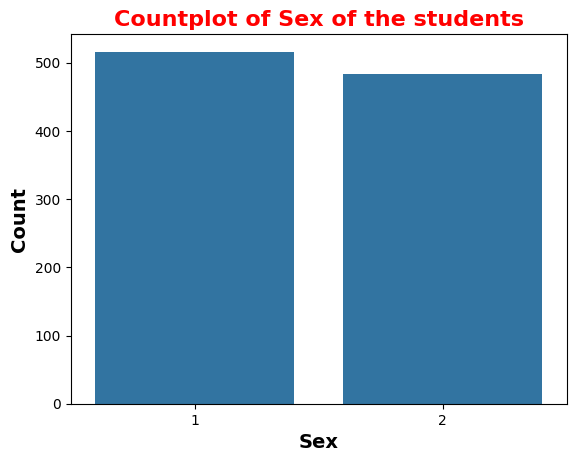

In [108]:
# Countplot of Sex of the students
sns.countplot(x = 'sex', data = df)
plt.title("Countplot of Sex of the students", fontsize = 16, color = "red", fontweight = 'bold')
plt.xlabel("Sex", fontsize = 14, fontweight = 'bold')
plt.ylabel("Count", fontsize = 14, fontweight = 'bold')
plt.show()

# **The satgpa dataset is not imbalanced with 51.6% data of male students and 48.4% data of female students.**

In [109]:
df = df.drop(["sat_v", "sat_m"], axis = 1)
df.head()

,sex,sat_sum,hs_gpa,fy_gpa
0,1,127,3.40,3.18
1,2,122,4.00,3.33
2,2,116,3.75,3.25
3,1,95,3.75,2.42
4,1,107,4.00,2.63


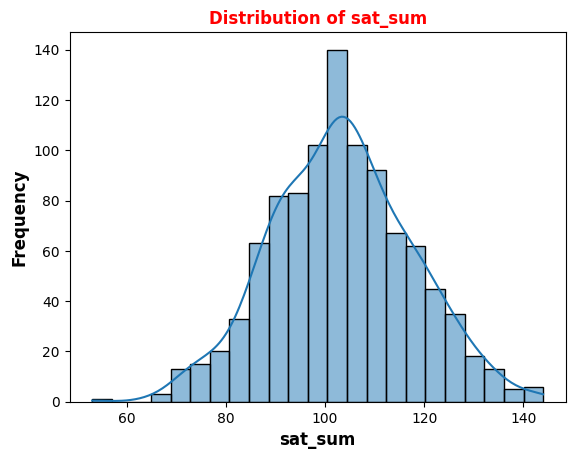

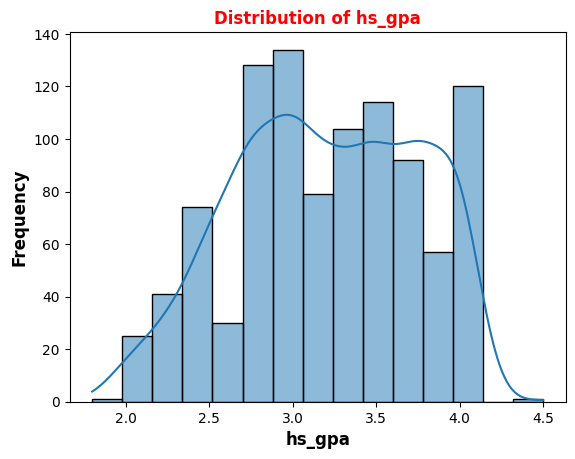

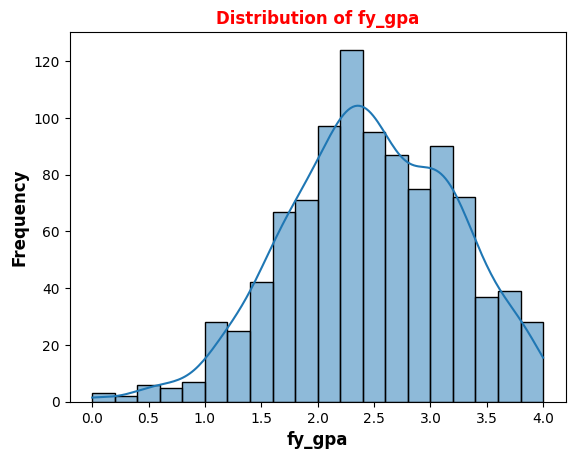

In [110]:
num_cols = ['sat_sum', 'hs_gpa', 'fy_gpa']

for col in num_cols:
    sns.histplot(df[col], kde = True)
    plt.title(f"Distribution of {col}", fontsize = 12, fontweight = 'bold', color = 'red')
    plt.xlabel(col, fontsize = 12, fontweight = 'bold')
    plt.ylabel("Frequency", fontsize = 12, fontweight = 'bold')
    plt.show()

# **Linear Regression Model:**

In [111]:
# Label encoding for the sex column. 1 = Male (label 0), 2 = Female (label 1)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df.head()

,sex,sat_sum,hs_gpa,fy_gpa
0,0,127,3.40,3.18
1,1,122,4.00,3.33
2,1,116,3.75,3.25
3,0,95,3.75,2.42
4,0,107,4.00,2.63


In [112]:
# Train test split
from sklearn.model_selection import train_test_split
X = df.drop('fy_gpa', axis = 1)
y = df['fy_gpa']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Train the model
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict
y_pred = lr.predict(X_test)

# Evaluation
from sklearn.metrics import r2_score, mean_squared_error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
rsquare = r2_score(y_test, y_pred)

# Intercept and coef of the line
print('Intercept of the model:', round(lr.intercept_, 2))
print('Coefficient of the line:', round(lr.coef_[0], 2))

# Linear Regression Model
coefficients = lr.coef_
intercept = lr.intercept_
feature_names = X_train.columns
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef}")
equation = f"fy_gpa = {intercept:.3f}"
for feature, coef in zip(feature_names, coefficients):
    equation += f" + ({coef:.3f} * {feature})"

print(equation)

Intercept of the model: -1.01
Coefficient of the line: 0.13
sex: 0.12842339424545546
sat_sum: 0.016049926307923415
hs_gpa: 0.5499771010778395
fy_gpa = -1.008 + (0.128 * sex) + (0.016 * sat_sum) + (0.550 * hs_gpa)


# **Interpretation:**

- Male students are predicted to have, on average, a 0.128 higher first-year GPA than female students, holding SAT score and high school GPA constant.

- For every 1-point increase in SAT score, first-year GPA increases by 0.016 points, holding sex and high school GPA constant.

- For every 1-point increase in high school GPA, first-year college GPA increases by 0.55 points, holding sex and SAT score constant. This is the strongest predictor in the model.

- The model indicates that high school GPA is the strongest predictor of first-year college GPA, with a one-point increase associated with a 0.55 increase in college GPA. SAT scores show a positive but smaller effect, while sex captures an average GPA difference between groups depending on encoding.

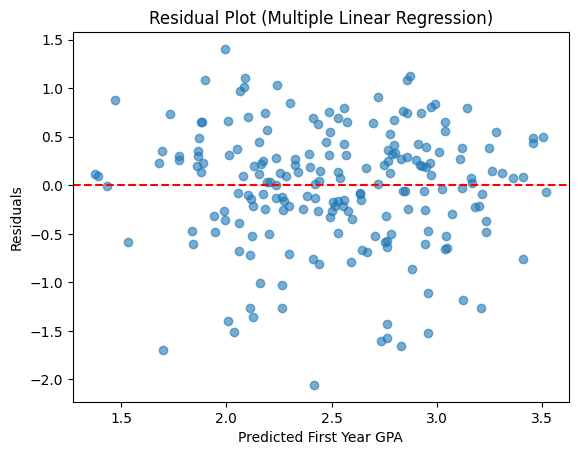

In [113]:
import matplotlib.pyplot as plt

y_pred = lr.predict(X_test)
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted First Year GPA")
plt.ylabel("Residuals")
plt.title("Residual Plot (Multiple Linear Regression)")
plt.show()

# **Additional dataset: Simple Linear Regression (SAT v/s GPA)**

In [114]:
# Import all the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.graph_objects as go
warnings.filterwarnings('ignore')

In [115]:
# Read the dataset and create a dataframe for analysis. Print the first 5 rows
df = pd.read_csv("/content/drive/MyDrive/Datasets/satvgpa.csv")
df.head()

,SAT,GPA
0,1714,2.40
1,1664,2.52
2,1760,2.54
3,1685,2.74
4,1693,2.83


In [116]:
# Print the last 5 rows
df.tail()

,SAT,GPA
95,1934,3.54
96,1861,3.58
97,1931,3.58
98,1933,3.59
99,1778,3.59


In [117]:
# Print the shape of the dataframe
df.shape

(100, 2)

In [118]:
# Statistical summary of the numerical columns of the dataframe
df.describe()

,SAT,GPA
count,100.000000,100.000000
mean,1850.760000,3.360500
std,101.566331,0.258845
min,1634.000000,2.400000
25%,1776.500000,3.270000
50%,1850.000000,3.410000
75%,1934.000000,3.520000
max,2050.000000,3.810000


In [119]:
# Data type of the attributes of the dataframe
df.dtypes

,0
SAT,int64
GPA,float64


In [120]:
# Info on the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SAT     100 non-null    int64  
 1   GPA     100 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 1.7 KB


In [121]:
df.columns

Index(['SAT', 'GPA'], dtype='object')

In [122]:
df.keys()

Index(['SAT', 'GPA'], dtype='object')

In [123]:
df.nunique()

,0
SAT,73
GPA,47


In [124]:
# Check for duplicate values
df.duplicated().sum()

np.int64(17)

In [125]:
# Check for missing values and their percentage
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine into a dataFrame for better readability
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_percentage})
missing_df

,Missing Values,Percentage (%)
SAT,0,0.0
GPA,0,0.0


# **The dataset is clean with no duplicates and no missing values!**

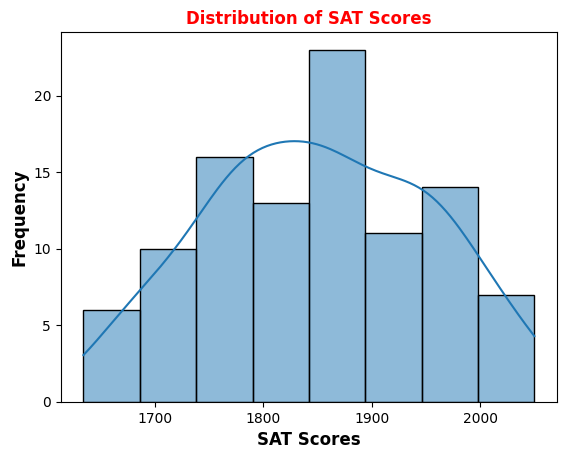

In [126]:
# Histplot of distribution of SAT Scores
sns.histplot(df['SAT'], kde = True)
plt.title("Distribution of SAT Scores", fontsize = 12, fontweight = 'bold', color = 'red')
plt.xlabel("SAT Scores", fontsize = 12, fontweight = 'bold')
plt.ylabel("Frequency", fontsize = 12, fontweight = 'bold')
plt.show()

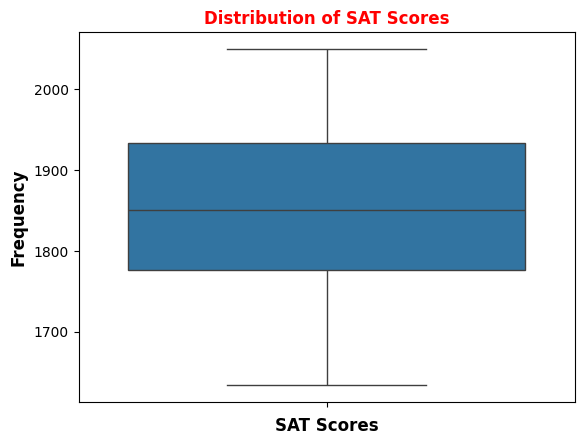

In [127]:
# Boxplot of distribution of SAT Scores
sns.boxplot(df['SAT'])
plt.title("Distribution of SAT Scores", fontsize = 12, fontweight = 'bold', color = 'red')
plt.xlabel("SAT Scores", fontsize = 12, fontweight = 'bold')
plt.ylabel("Frequency", fontsize = 12, fontweight = 'bold')
plt.show()

# **Linear Regression Model:**

In [128]:
X = np.array(df['SAT']).reshape(-1,1)
y = np.array(df['GPA'])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

# Training the model on the training set
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X, y)

# Predicting the test set results
y_pred = lr.predict(X_test)

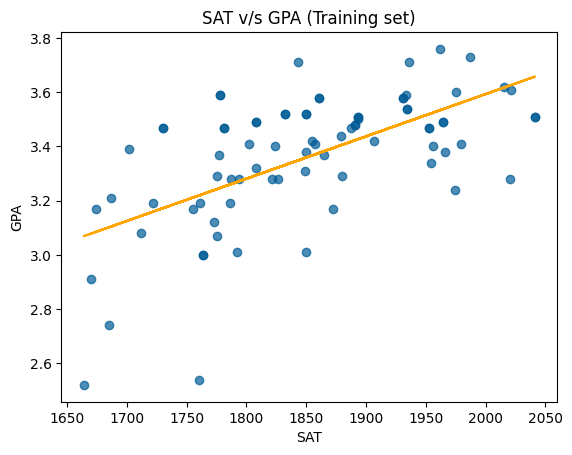

In [129]:
# Visualising training set results
plt.scatter(X_train, y_train, color = '#005b96', alpha= 0.7)
plt.plot(X_train, lr.predict(X_train), color = "orange")
plt.xlabel('SAT')
plt.ylabel('GPA')
plt.title('SAT v/s GPA (Training set)')
plt.show()

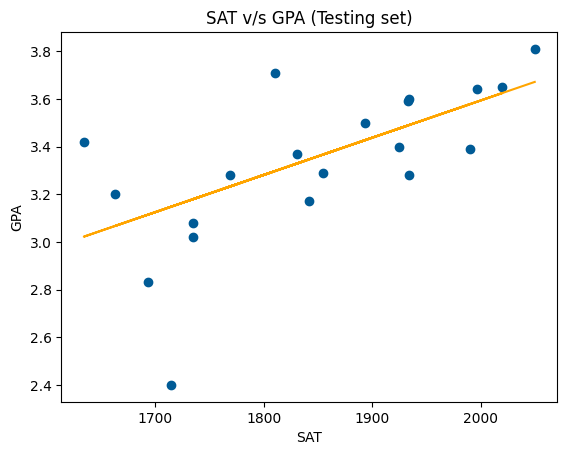

In [130]:
# Visualising test set results
plt.scatter(X_test, y_test, color= '#005b96')
plt.plot(X_test, lr.predict(X_test), color = "orange")
plt.xlabel('SAT')
plt.ylabel('GPA')
plt.title('SAT v/s GPA (Testing set)')
plt.show()

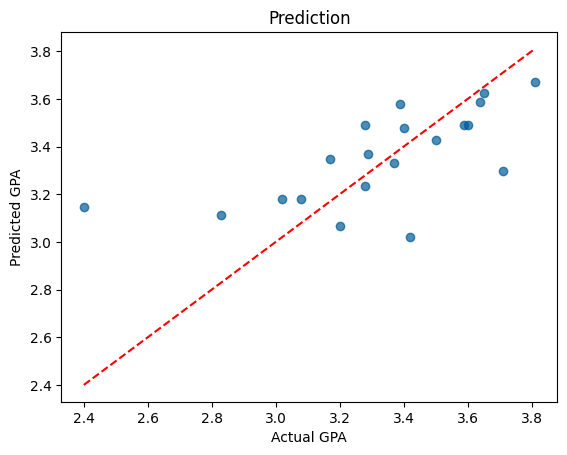

In [131]:
# Plotting predicted value vs Actual value
plt.scatter(y_test, y_pred, alpha = 0.7, color = '#005b96')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = 'red', linestyle = '--')
plt.xlabel('Actual GPA')
plt.ylabel('Predicted GPA')
plt.title('Prediction')
plt.show()

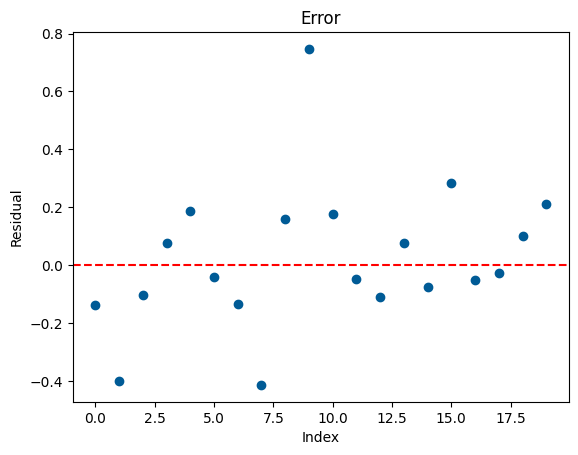

In [132]:
# Plotting the residuals
resid = y_pred - y_test
idx = np.arange(len(resid))
plt.scatter(idx, resid, color = '#005b96')
plt.axhline(0, color = "red", linestyle = "--")
plt.xlabel('Index')
plt.ylabel('Residual')
plt.title('Error')
plt.show()

In [133]:
# Evaluation
from sklearn.metrics import r2_score, mean_squared_error

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
rsquare = r2_score(y_test, y_pred)

print('Root mean square error:', rmse)
print('R-square:', rsquare)

# Intercept and coef of the line
print('Intercept of the model:', round(lr.intercept_, 2))
print('Coefficient of the line:', round(lr.coef_[0], 2))

# Linear Regression Model
slope = lr.coef_[0]
intercept = lr.intercept_
print(f"GPA = {intercept:.3f} + {slope:.3f} * SAT")

Root mean square error: 0.2446848577157831
R-square: 0.4252750398219014
Intercept of the model: 0.47
Coefficient of the line: 0.0
GPA = 0.471 + 0.002 * SAT


# **Interpretation:**

- For every 1-point increase in SAT score, the predicted GPA increases by 0.002 points, on average.

- The intercept (0.471) represents the predicted GPA when SAT score is 0, which has no practical meaning here and mainly serves as a baseline for the model.

- A 100-point increase in SAT score is associated with an average 0.2 increase in GPA.

# **Recommendations / Implications:**

- SAT score alone is not sufficient to accurately predict academic performance.

- College admissions and academic support programs should place greater emphasis on high school GPA rather than SAT scores alone when predicting student success.

- Standardized tests add value but should be treated as supplementary indicators, not primary decision drivers.

- Observed gender differences suggest the need for additional non-academic factors (study habits, course load, support systems) in future models.

- Institutions relying only on standardized test scores may misestimate student potential.